In [26]:
import numpy as np
import pydtmc
import pickle
import multiprocessing as mp
from functools import partial
import os
from utils import reorder_transition_matrix
import matplotlib.pyplot as plt

In [24]:
def interaction_verticality_1(tm):
    """
    Calculate vertical transport score using monte carlo simulation, and the fraction of vertical steps.
    Args:
        tm np.array: transition matrix, where the first state is the nucleus and the last state is cytoplasm.
        states (i+1) through (i+9) are on the same height for every i%8 = 0.
    Returns: Vertical transport score. (1 = fully vertical, 0 = fully horizontal)
    """
    mc = pydtmc.MarkovChain(tm)
    N_SIMS = 50
    N_STEPS = 1000

    vertical_steps = 0
    horizontal_steps = 0
    for _ in range(N_SIMS):
        sim = mc.simulate(steps = N_STEPS,
                    initial_state = 0, # # initial_state = len(tm)-1,
                    output_indices=True)
        sim = np.array(sim)
        for i in range(N_STEPS - 1):
            state_1 = sim[i]
            state_2 = sim[i+1]
            if (state_1 != 0) and (state_1 != len(tm)-1) and (state_2 != 0) and (state_2 != len(tm)-1):
                spoke = state_1 % 8
                if (state_2 % 8 == spoke):
                    vertical_steps += 1
                else:
                    horizontal_steps += 1
    return vertical_steps / (vertical_steps + horizontal_steps)

def spatial_verticality_2(tm, n=1):
    """
    Calculate vertical transport score using monte carlo simulation, and the fraction of the n most prominent spokes.
    Args:
        tm np.array: transition matrix, where the first state is the nucleus and the last state is cytoplasm.
        states (i+1) through (i+9) are on the same height for every i%8 = 0.
    Returns: Vertical transport score. (1 = fully vertical, 0 = fully horizontal)
    """
    mc = pydtmc.MarkovChain(tm)
    N_SIMS = 100
    N_STEPS = 1000


    most_prominent_spoke_fractions = []
    for _ in range(N_SIMS):
        sim = mc.simulate(steps = N_STEPS,
                    # initial_state = 10, # ~ center of pore
                    output_indices=True)
        # Slice until first occurence:
        sim = np.array(sim)
        indices = np.where((sim == 0) | (sim == len(tm) - 1))[0]
        if len(indices) != 0:
            # raise Exception("Didn't reach nucleus or cytoplasm")
            first_idx = indices[0]
            sim = sim[:first_idx]
        sim = sim - 1 # Remove nucleus state
        sim = sim % 8
        spoke_counts = np.bincount(sim)
        
        # Sort spoke counts in descending order and take the n largest counts
        sorted_counts = np.sort(spoke_counts)[::-1]
        sum_n_most_prominent = np.sum(sorted_counts[:n])
        total_counts = np.sum(spoke_counts)
        most_prominent_spoke_fractions.append(sum_n_most_prominent / total_counts)
    return np.mean(most_prominent_spoke_fractions)

def interaction_verticality_2(tm, n=1, bottom_state=40, top_state=200):
    """
    Calculate vertical transport score using monte carlo simulation, and the fraction of the n most prominent spokes.
    Args:
        tm np.array: transition matrix, where the first state is the nucleus and the last state is cytoplasm.
        states (i+1) through (i+9) are on the same height for every i%8 = 0.
    Returns: Vertical transport score. (1 = fully vertical, 0 = fully horizontal)
    """
    mc = pydtmc.MarkovChain(tm)
    N_SIMS = 100
    # N_STEPS = 10000


    most_prominent_spoke_fractions = []
    for _ in range(N_SIMS):
        cur_state = np.random.randint(bottom_state, top_state)
        sim = [cur_state]
        while cur_state > bottom_state and cur_state < top_state:
            cur_state = np.random.choice(range(len(tm)), p=tm[cur_state])
            sim.append(cur_state)
        sim = np.array(sim)
        
        
        
        # sim = mc.simulate(steps = N_STEPS,
        #             initial_state = initial_state,
        #             output_indices=True)
        # # Slice until first occurence:
        # sim = np.array(sim)
        # indices = np.where((sim <= bottom_state) | (sim >= top_state))[0]
        # if len(indices) != 0:
        #     # raise Exception("Didn't reach nucleus or cytoplasm")
        #     first_idx = indices[0]
        #     sim = sim[:first_idx]
        #     if first_idx == 0:
        #         continue
        
        sim = sim - 1 # Remove nucleus state
        sim = sim % 8
        spoke_counts = np.bincount(sim)
        
        # Sort spoke counts in descending order and take the n largest counts
        sorted_counts = np.sort(spoke_counts)[::-1]
        sum_n_most_prominent = np.sum(sorted_counts[:n])
        total_counts = np.sum(spoke_counts)
        most_prominent_spoke_fractions.append(sum_n_most_prominent / total_counts)
    return np.mean(most_prominent_spoke_fractions)

def interaction_verticality_from_path(matrix_path, variant=1, n=1, bottom_state=40, top_state=200):
    with open(matrix_path, "rb") as f:
        tm, states = pickle.load(f)
        
    # Load anchor coordinates
    with open(f"data/anchor_coordinates.pickle", "rb") as f:
        anchor_coordinates = pickle.load(f)
    
    # Sort anchor coordinates by Z and reorder transition matrix
    anchor_coordinates = dict(sorted(anchor_coordinates.items(), key=lambda x: x[1][2]))
    new_states = ["nuc"] + list(anchor_coordinates.keys()) + ["cyt"]
    tm = reorder_transition_matrix(tm, states, new_states)  
    
    if variant == 1:
        return interaction_verticality_1(tm)
    if variant == 2:
        return interaction_verticality_2(tm, n=n, top_state=top_state, bottom_state=bottom_state)
    else:
        raise ValueError(f"Variant {variant} not implemented")
    
def spatial_verticality_from_path(matrix_path, variant=1, n=1):
    with open(matrix_path, "rb") as f:
        tm = pickle.load(f)
    
    if variant == 1:
        return interaction_verticality_1(tm)
    if variant == 2:
        return spatial_verticality_2(tm, n)
    else:
        raise ValueError(f"Variant {variant} not implemented")

In [ ]:
interaction_verticality_from_path(f"data/transition_matrices/interactions-150-180-symmetric-{100}ns.pickle", variant=1)

0.509165538435089

In [5]:
for n in [1,2,3]:
    verticality = interaction_verticality_from_path(f"data/transition_matrices/interactions-150-180-symmetric-{100}ns.pickle", variant=2, n=n)
    print(f"{n} verticality for interactions: {verticality}")

1 verticality for interactions: 0.7320505721668513
2 verticality for interactions: 0.9297177369653642
3 verticality for interactions: 0.9811313131313131


In [25]:
def compute_verticality(args):
    bottom_state, top_state, n = args
    verticality = interaction_verticality_from_path(
        f"data/transition_matrices/interactions-150-180-symmetric-{100}ns.pickle", 
        variant=2, 
        n=n, 
        bottom_state=bottom_state, 
        top_state=top_state
    )
    return bottom_state, top_state, verticality

# Main calculation
def calculate_verticalities(n):
    state_range = range(1, 218)
    verticalities = np.zeros((218, 218))
    args_list = [(bottom_state, top_state, n) for top_state in state_range for bottom_state in range(top_state)]
    num_cpus = len(os.sched_getaffinity(0))
    print(f"Using {num_cpus} CPUs")
    with mp.Pool(processes=num_cpus) as pool:
        results = pool.map(compute_verticality, args_list)
    for bottom_state, top_state, verticality in results:
        verticalities[bottom_state, top_state] = verticality
    return verticalities

verticalities = calculate_verticalities(1)

Using 12 CPUs


In [35]:
with open("data/verticality_matrices/interactions-150-180-symmetric-100ns-1spoke.pickle", "wb") as f:
    pickle.dump(verticalities, f)

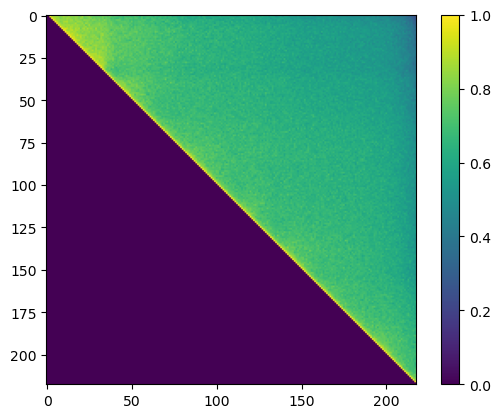

In [33]:
plt.imshow(verticalities)
plt.colorbar()
plt.show()

In [120]:
for n in [1,2,3]:
    for layers in [3,5,7,10]:
        verticality = spatial_verticality_from_path(f"data/transition_matrices/spatial-150-180-symmetric-{layers}layers.pickle", variant=2, n=n)
        print(f"{n} verticality for {layers} layers: {verticality}")

/tmp/ipykernel_1910481/3024979523.py:86: DeprecationWarning: Calling nonzero on 0d arrays is deprecated, as it behaves surprisingly. Use `atleast_1d(cond).nonzero()` if the old behavior was intended. If the context of this warning is of the form `arr[nonzero(cond)]`, just use `arr[cond]`.
  indices = np.where((sim == 0) | (sim == len(tm) - 1))[0]


1 verticality for 3 layers: 0.65018981018981
1 verticality for 5 layers: 0.35490509490509503
1 verticality for 7 layers: 0.35663336663336664
1 verticality for 10 layers: 0.3459440559440559
2 verticality for 3 layers: 0.85006993006993
2 verticality for 5 layers: 0.4986713286713287
2 verticality for 7 layers: 0.5295504495504495
2 verticality for 10 layers: 0.5362437562437561
3 verticality for 3 layers: 0.8926773226773227
3 verticality for 5 layers: 0.6502997002997003
3 verticality for 7 layers: 0.6417482517482518
3 verticality for 10 layers: 0.6506593406593406


Conclusion: there is a difference in the results in the interaction markov chain and the spatial markov chain.  

1 verticality for interactions: 0.1708491508491508
2 verticality for interactions: 0.31674325674325676
3 verticality for interactions: 0.4494405594405595

1 verticality for 10 layers: 0.35498501498501506
2 verticality for 10 layers: 0.5305294705294705
3 verticality for 10 layers: 0.6294205794205794

Also, the spatial results can probably get even higher through a small rotation of the borders. I am not sure weather the true verticality is more similar to the spatial model. While we saw previously that in the original simulation most NTRs tend to stick to a quarter of the pore, those results might be quite skewed, since I looked at only a very short timespan, and took the NTRS that tranported in it, thus ignoring the NTRs that "took their time" in the pore (and probably moving more horizontally). 

Even so, the spatial and interaction models may have different predictive capabilities, each better in different matrix. 

IMPORTANT: I feel like the comparison is not fair! In the spatial model we only look inside the pore, while in the interactions model we consider FGs on the outside too. In siegfreed musser, it appears outside movement is a lot more horizontal. This is also very apparent in the cytoplamic side of the interactions transition matrix (interestingly, that is not the case in the nuclear side). I think I should limit the verticality algorithm to the  

its high now. 
in the center!!!

NSP1 acts as a horizontal distribution center? look at it's square it's so yellow.
